
Imports

In [109]:
import os, json, warnings, re, hashlib, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field
from tqdm import tqdm
from PIL import Image
import joblib
from xgboost import callback
import xgboost as xgb

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import xgboost as xgb
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_percentage_error


import nltk
from nltk.corpus import stopwords

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords", quiet=True)

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)
np.random.seed(42)
print("[OK] Imports OK")




[OK] Imports OK


In [110]:
@dataclass
class Config:
    seed: int = 42

    # Chemins
    csv_path: str = "Data/merged_listings_model_ready.csv"
    csv_out: str = 'Data/merged_listings_cleaned_model_ready.csv'
    images_dir: str = "Data/images"
    cache_dir: str = "Data/cache"
    output_dir: str = "outputs"
    target: str = "price"

    # Vision
    vision_dims_raw: int = 2048        # dims ResNet50
    vision_dims_pca: int = 64          # NOUVEAU : réduction PCA
    max_images: int = 3

    # NLP
    nlp_max_features: int = 2500
    nlp_components: int = 20
    nlp_ngram_range: Tuple[int, int] = (1, 2)

    # XGBoost
    xgb_n_estimators: int = 1000       # plus élevé + early stopping
    xgb_learning_rate: float = 0.05    # réduit pour profiter de early stop
    xgb_max_depth: int = 7
    xgb_subsample: float = 0.85
    xgb_colsample_bytree: float = 0.8  # NOUVEAU
    xgb_early_stopping_rounds: int = 50  # NOUVEAU

    # Cross-validation
    cv_folds: int = 5

    # Features
    categorical_features: List[str] = field(default_factory=lambda: [
        "governorate", "city", "property_type", "seller_type"
    ])
    numerical_features: List[str] = field(default_factory=lambda: [
        "surface_m2", "rooms", "bedrooms", "bathrooms",
        "image_count", "amenity_score", "listing_quality"
    ])

config = Config()
os.makedirs(config.cache_dir, exist_ok=True)
os.makedirs(config.output_dir, exist_ok=True)
print(f"Cache: {config.cache_dir} | Outputs: {config.output_dir}")
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(config.output_dir, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler("vision_extraction.log")
    ]
)

logger = logging.getLogger("Vision")


Cache: Data/cache | Outputs: outputs


In [111]:
config = Config()
os.makedirs(config.cache_dir, exist_ok=True)
os.makedirs(config.output_dir, exist_ok=True)
print(f"Cache: {config.cache_dir} | Outputs: {config.output_dir}")


Cache: Data/cache | Outputs: outputs


## 1. Data Cleaning & Feature Engineering


In [112]:
df = pd.read_csv(config.csv_path, low_memory=False)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
n0=len(df)

Dataset loaded: 31257 rows, 40 columns


In [113]:
df.head()

,id,listing_id,listing_url,source,title,property_type,transaction_type,price,currency,surface_m2,rooms,bedrooms,bathrooms,country,governorate,city,description,image_count,image_urls,seller_type,has_elevator,has_basement,has_heating,has_air_conditioning,has_garden,has_furniture,has_parking,has_pool,has_security,has_standing,has_terrace,has_sea_view,description_word_count,has_images,is_agency,is_price_imputed,has_surface,has_rooms_info,has_bathrooms_info,has_bedrooms_info
0,1,7836763,https://www.mubawab.tn/fr/a/7836763/a-vendre-v...,mubawab,A vendre villa jumelee a mourouj 3,Villa,Sale,320000.0,TND,413.0,NaN,NaN,NaN,Tunisia,Ben Arous,El Mourouj,A vendre une villa jumelée comprenant un duple...,8,"[""https://www.mubawab-media.com/ad/7/836/763F/...",agency,False,False,False,False,False,False,True,False,False,True,True,False,45,True,1,False,False,False,False,False
1,2,8187888,https://www.mubawab.tn/fr/a/8187888/charmant-d...,mubawab,"Charmant Duplex à Ain Zaghouan, Tunis 200m²",Office,Sale,600000.0,TND,200.0,NaN,NaN,NaN,Tunisia,Zaghouan,Zaghouan,[EN EXCLUSIVITÉ] Magnifique Duplex S4 à Ain Za...,24,"[""https://www.mubawab-media.com/ad/8/187/888F/...",agency,False,False,False,True,True,False,True,False,False,False,True,False,120,True,1,False,True,False,False,False
2,3,8187887,https://www.mubawab.tn/fr/a/8187887/duplex-s3-...,mubawab,Duplex S3 à Ain Zaghouan Nord,Building,Sale,520000.0,TND,157.0,NaN,NaN,NaN,Tunisia,Zaghouan,Zaghouan,"on vous propose à la vente un duplex S3, dans ...",25,"[""https://www.mubawab-media.com/ad/8/187/887F/...",agency,False,False,False,False,True,False,False,False,False,False,True,False,84,True,1,False,False,False,False,False
3,4,8080588,https://www.mubawab.tn/fr/a/8080588/superbe-fe...,mubawab,Superbe Ferme en pleine activité à Soliman,Farm,Sale,990000.0,TND,5863.0,NaN,NaN,NaN,Tunisia,Nabeul,Soliman,A vendre une Superbe Ferme clôturé en pleine a...,20,"[""https://www.mubawab-media.com/ad/8/080/588F/...",agency,False,False,False,True,False,False,True,False,True,False,False,False,94,True,1,False,False,False,False,False
4,6,8294372,https://www.mubawab.tn/fr/a/8294372/%C3%A0-ven...,mubawab,À vendre: Terrain agricole de 3600 m²,Land,Sale,619400.0,TND,3600.0,NaN,NaN,NaN,Tunisia,Sousse,KalâA Kebira,À vendre : Terrain agricole de 3600 m² en plei...,5,"[""https://www.mubawab-media.com/ad/8/294/372F/...",agency,False,False,False,True,False,False,False,False,False,False,False,False,94,True,1,True,True,False,False,False


In [114]:
df.describe()

,id,price,surface_m2,rooms,bedrooms,bathrooms,image_count,description_word_count,is_agency
count,31257.000000,3.125700e+04,3.125700e+04,8563.000000,8.864000e+03,6.563000e+03,31257.000000,31257.000000,31257.000000
mean,27915.108936,3.207028e+08,9.499016e+03,3.187084,5.442150e+03,1.622686e+04,6.788047,70.296957,0.472534
std,20861.986474,3.745826e+10,4.546954e+05,1.388220,3.540718e+05,8.261645e+05,5.552881,65.929423,0.699159
min,1.000000,-2.000000e+00,1.000000e+00,0.000000,0.000000e+00,-2.000000e+00,0.000000,1.000000,-1.000000
25%,8145.000000,2.000000e+05,1.131450e+02,2.000000,2.000000e+00,1.000000e+00,2.000000,28.000000,0.000000
50%,21613.000000,3.500000e+05,2.215000e+02,3.000000,2.000000e+00,1.000000e+00,6.000000,54.000000,1.000000
75%,49766.000000,6.630000e+05,5.000000e+02,4.000000,3.000000e+00,2.000000e+00,10.000000,92.000000,1.000000
max,59493.000000,6.300001e+12,5.804472e+07,42.000000,2.432801e+07,5.804472e+07,46.000000,1815.000000,1.000000


In [115]:
df[config.target].isnull().sum()

np.int64(0)

In [116]:
df['surface_m2'].isnull().sum()  

np.int64(0)

In [117]:
print(f"min :{df[config.target].min()}")
print(f"min :{df[config.target].max()}")

min :-2.0
min :6300000700000.0


In [118]:
df.describe()

,id,price,surface_m2,rooms,bedrooms,bathrooms,image_count,description_word_count,is_agency
count,31257.000000,3.125700e+04,3.125700e+04,8563.000000,8.864000e+03,6.563000e+03,31257.000000,31257.000000,31257.000000
mean,27915.108936,3.207028e+08,9.499016e+03,3.187084,5.442150e+03,1.622686e+04,6.788047,70.296957,0.472534
std,20861.986474,3.745826e+10,4.546954e+05,1.388220,3.540718e+05,8.261645e+05,5.552881,65.929423,0.699159
min,1.000000,-2.000000e+00,1.000000e+00,0.000000,0.000000e+00,-2.000000e+00,0.000000,1.000000,-1.000000
25%,8145.000000,2.000000e+05,1.131450e+02,2.000000,2.000000e+00,1.000000e+00,2.000000,28.000000,0.000000
50%,21613.000000,3.500000e+05,2.215000e+02,3.000000,2.000000e+00,1.000000e+00,6.000000,54.000000,1.000000
75%,49766.000000,6.630000e+05,5.000000e+02,4.000000,3.000000e+00,2.000000e+00,10.000000,92.000000,1.000000
max,59493.000000,6.300001e+12,5.804472e+07,42.000000,2.432801e+07,5.804472e+07,46.000000,1815.000000,1.000000



# ÉTAPE 2 — Filtre PRIX
#   Données réelles :  min=-2, max=6.3 trillions
#   Bornes retenues :  P1 observé ≈ 0  →  5K TND (logique marché)
#                      P99 observé ≈ 5.5M  →  15M TND (sécurité)


In [119]:
print(df[config.target].quantile(0.01))
print(df[config.target].quantile(0.99))

0.0
5500000.0


In [120]:
PRICE_MIN = 5000   # < 5K TND = erreur ou données test
PRICE_MAX = 15000000  # > 15M TND = erreur de saisie (tri11ions observés)
before = len(df)
df = df[df['price'].between(PRICE_MIN, PRICE_MAX)]
print(f"[2] Filtre prix [{PRICE_MIN:,} – {PRICE_MAX:,} TND] : {len(df):,}  (-{before-len(df):,})")

[2] Filtre prix [5,000 – 15,000,000 TND] : 30,003  (-1,254)


# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 3 — Filtre SURFACE
#   Données réelles :  min=1, max=58M m² 
#   Bornes retenues :  10 m² (studio minimal)  →  10 000 m² (grand terrain)
#   Note : P95=2000 m², P99=60000 m² — on coupe à 10K pour garder terrains raisonnables
# ─────────────────────────────────────────────────────────────────────────────

In [121]:
print(df['surface_m2'].quantile(0.01))
print(df['surface_m2'].quantile(0.95))
print(df['surface_m2'].quantile(0.99))


31.0
1975.0
60000.0


In [122]:
SURFACE_MIN = 10        # < 10 m² = données corrompues
SURFACE_MAX = 10_000    # > 10 000 m² = outlier (58M observé = bug de saisie)

before = len(df)
df = df[df['surface_m2'].between(SURFACE_MIN, SURFACE_MAX)]
print(f"surface [{SURFACE_MIN} – {SURFACE_MAX:,} m²] : {len(df):,}  (-{before-len(df):,})")

surface [10 – 10,000 m²] : 29,196  (-807)


# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 4 — Filtre PRIX/m²  (outliers contextuels)
#   Prix/m² médian par type :  Apt=2927, Land=432, Farm=243, Duplex=3300
#   On filtre les valeurs absurdes : < 50 TND/m² ou > 30 000 TND/m²
#   → supprime les très rares combinaisons surface/prix incohérentes
# ─────────────────────────────────────────────────────────────────────────────

In [123]:
df['_price_per_m2'] = df['price'] / df['surface_m2']
print(df['_price_per_m2'].quantile(0.01))
print(df['_price_per_m2'].quantile(0.95))
print(df['_price_per_m2'].quantile(0.99))


35.498402555910545
6546.1877184790155
18343.666666666515


In [124]:
PPM2_MIN = 50         # < 50 TND/m² = quasi-gratuit (erreur)
PPM2_MAX = 30_000     # > 30 000 TND/m² = luxe extrême (Farm P95=15361, garder marge)

before = len(df)
df = df[df['_price_per_m2'].between(PPM2_MIN, PPM2_MAX)]
df = df.drop(columns=['_price_per_m2'])
print(f"Filtre prix/m² [{PPM2_MIN} – {PPM2_MAX:,} TND/m²] : {len(df):,}  (-{before-len(df):,})")

Filtre prix/m² [50 – 30,000 TND/m²] : 28,597  (-599)


# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 5 — Filtre BEDROOMS
#   Données réelles : max=74.0 (= surface m² copiée par erreur !)
#   Bornes retenues : 0 – 20 chambres
# ─────────────────────────────────────────────────────────────────────────────

In [125]:
print(df['bedrooms'].max())
print(df['bedrooms'].min())
print(df['bedrooms'].quantile(0.99))

74.0
0.0
8.0


In [126]:
if 'bedrooms' in df.columns:
    before = len(df)
    df['bedrooms'] = df['bedrooms'].clip(lower=0, upper=20)
    print(before,len(df))

28597 28597


# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 6 — Filtre BATHROOMS
#   Données réelles : min=-2, max=148500.0 (= surface copiée !)
#   Bornes retenues : 0 – 15
# ─────────────────────────────────────────────────────────────────────────────

In [127]:
print(df['bathrooms'].max())
print(df['bathrooms'].min())
print(df['bathrooms'].quantile(0.99))

148500.0
-2.0
5.0


In [128]:
if 'bathrooms' in df.columns:
    df['bathrooms'] = df['bathrooms'].clip(lower=0, upper=15)
    print(len(df))

28597


# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 7 — Filtre ROOMS
#   Données réelles : max=42 (acceptable pour un immeuble)
#   Bornes retenues : 0 – 30
# ─────────────────────────────────────────────────────────────────────────────


In [129]:
if 'rooms' in df.columns:
    df['rooms'] = df['rooms'].clip(lower=0, upper=42)
    print(len(df))

28597


In [130]:
df.describe()

,id,price,surface_m2,rooms,bedrooms,bathrooms,image_count,description_word_count,is_agency
count,28597.000000,2.859700e+04,28597.000000,8502.000000,7869.000000,5571.000000,28597.000000,28597.000000,28597.000000
mean,27361.639717,5.928924e+05,391.878589,3.183604,2.570466,1.374798,6.898276,71.412736,0.526279
std,21004.974509,8.061234e+05,706.428569,1.387442,1.482407,1.051751,5.633510,66.484633,0.660611
min,1.000000,5.500000e+03,10.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-1.000000
25%,7732.000000,2.200000e+05,113.145000,2.000000,2.000000,1.000000,2.000000,29.000000,0.000000
50%,19420.000000,3.600000e+05,214.000000,3.000000,2.000000,1.000000,6.000000,56.000000,1.000000
75%,49801.000000,6.800000e+05,500.000000,4.000000,3.000000,1.000000,10.000000,93.000000,1.000000
max,59493.000000,1.500000e+07,10000.000000,42.000000,20.000000,15.000000,46.000000,1815.000000,1.000000


In [131]:
df.isna().sum()

id                            0
listing_id                    0
listing_url                   0
source                        0
title                         0
property_type                 0
transaction_type              0
price                         0
currency                      0
surface_m2                    0
rooms                     20095
bedrooms                  20728
bathrooms                 23026
country                       0
governorate                   0
city                         10
description                   0
image_count                   0
image_urls                  219
seller_type                2664
has_elevator                  0
has_basement                  0
has_heating                   0
has_air_conditioning          0
has_garden                    0
has_furniture                 0
has_parking                   0
has_pool                      0
has_security                  0
has_standing                  0
has_terrace                   0
has_sea_

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 8 — Filtre IMAGE_COUNT
#   Données réelles :  min=0, max=46 (raisonnable)
#   Bornes retenues :  0 – 50 (aucun impact)
# ─────────────────────────────────────────────────────────────────────────────

In [132]:
if 'image_count' in df.columns:
    df['image_count'] = df['image_count'].clip(lower=0, upper=50)
    

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 9 — Outliers par property_type (IQR ×3 par groupe)
#   Suppression des prix aberrants DANS chaque type de bien
#   Ex : un Land à 14M TND est suspect si tous les autres sont < 3M
# ─────────────────────────────────────────────

In [133]:
before = len(df)
outlier_mask = pd.Series(False, index=df.index)

for ptype, group in df.groupby('property_type'):
    prices = group['price']
    Q1 = prices.quantile(0.25)
    Q3 = prices.quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 3 * IQR    # IQR×3 (moins agressif que ×1.5)
    high = Q3 + 3 * IQR

    mask = (prices < low) | (prices > high)
    outlier_mask[mask.index[mask]] = True
    n_out = mask.sum()
    if n_out > 0:
        print(f"     {str(ptype):20s} : {n_out:4d} outliers prix  [fence: {low:>10,.0f} – {high:>10,.0f}]")

df = df[~outlier_mask]
print(f"[9] Outliers IQR×3 par property_type : {len(df):,}  (-{before-len(df):,})")


     Apartment            :  321 outliers prix  [fence:   -450,000 –  1,160,000]
     Building             :   23 outliers prix  [fence: -1,140,000 –  2,570,000]
     Commercial           :   57 outliers prix  [fence:   -710,000 –  1,145,000]
     House                :  143 outliers prix  [fence: -1,072,000 –  1,941,500]
     Land                 :  365 outliers prix  [fence: -1,270,000 –  2,090,000]
     Office               :   61 outliers prix  [fence:   -320,000 –    940,000]
     Other                :   18 outliers prix  [fence: -1,650,000 –  2,550,000]
     Unknown              :   21 outliers prix  [fence:   -740,000 –  1,430,000]
     Villa                :   80 outliers prix  [fence: -1,650,000 –  3,600,000]
[9] Outliers IQR×3 par property_type : 27,508  (-1,089)


# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 10 — Suppression des doublons (si listing_id existe)
# ─────────────────────────────────────────────────────────────────────────────

In [134]:
df['listing_id'].duplicated().sum()

np.int64(200)

In [135]:
if 'listing_id' in df.columns:
    before = len(df)
    df = df.drop_duplicates(subset='listing_id', keep='first')
    print(f"[10] Doublons listing_id supprimés : {len(df):,}  (-{before-len(df):,})")

[10] Doublons listing_id supprimés : 27,308  (-200)


In [136]:
df.head()

,id,listing_id,listing_url,source,title,property_type,transaction_type,price,currency,surface_m2,rooms,bedrooms,bathrooms,country,governorate,city,description,image_count,image_urls,seller_type,has_elevator,has_basement,has_heating,has_air_conditioning,has_garden,has_furniture,has_parking,has_pool,has_security,has_standing,has_terrace,has_sea_view,description_word_count,has_images,is_agency,is_price_imputed,has_surface,has_rooms_info,has_bathrooms_info,has_bedrooms_info
0,1,7836763,https://www.mubawab.tn/fr/a/7836763/a-vendre-v...,mubawab,A vendre villa jumelee a mourouj 3,Villa,Sale,320000.0,TND,413.0,NaN,NaN,NaN,Tunisia,Ben Arous,El Mourouj,A vendre une villa jumelée comprenant un duple...,8,"[""https://www.mubawab-media.com/ad/7/836/763F/...",agency,False,False,False,False,False,False,True,False,False,True,True,False,45,True,1,False,False,False,False,False
1,2,8187888,https://www.mubawab.tn/fr/a/8187888/charmant-d...,mubawab,"Charmant Duplex à Ain Zaghouan, Tunis 200m²",Office,Sale,600000.0,TND,200.0,NaN,NaN,NaN,Tunisia,Zaghouan,Zaghouan,[EN EXCLUSIVITÉ] Magnifique Duplex S4 à Ain Za...,24,"[""https://www.mubawab-media.com/ad/8/187/888F/...",agency,False,False,False,True,True,False,True,False,False,False,True,False,120,True,1,False,True,False,False,False
2,3,8187887,https://www.mubawab.tn/fr/a/8187887/duplex-s3-...,mubawab,Duplex S3 à Ain Zaghouan Nord,Building,Sale,520000.0,TND,157.0,NaN,NaN,NaN,Tunisia,Zaghouan,Zaghouan,"on vous propose à la vente un duplex S3, dans ...",25,"[""https://www.mubawab-media.com/ad/8/187/887F/...",agency,False,False,False,False,True,False,False,False,False,False,True,False,84,True,1,False,False,False,False,False
3,4,8080588,https://www.mubawab.tn/fr/a/8080588/superbe-fe...,mubawab,Superbe Ferme en pleine activité à Soliman,Farm,Sale,990000.0,TND,5863.0,NaN,NaN,NaN,Tunisia,Nabeul,Soliman,A vendre une Superbe Ferme clôturé en pleine a...,20,"[""https://www.mubawab-media.com/ad/8/080/588F/...",agency,False,False,False,True,False,False,True,False,True,False,False,False,94,True,1,False,False,False,False,False
4,6,8294372,https://www.mubawab.tn/fr/a/8294372/%C3%A0-ven...,mubawab,À vendre: Terrain agricole de 3600 m²,Land,Sale,619400.0,TND,3600.0,NaN,NaN,NaN,Tunisia,Sousse,KalâA Kebira,À vendre : Terrain agricole de 3600 m² en plei...,5,"[""https://www.mubawab-media.com/ad/8/294/372F/...",agency,False,False,False,True,False,False,False,False,False,False,False,False,94,True,1,True,True,False,False,False


In [137]:
df.tail()


,id,listing_id,listing_url,source,title,property_type,transaction_type,price,currency,surface_m2,rooms,bedrooms,bathrooms,country,governorate,city,description,image_count,image_urls,seller_type,has_elevator,has_basement,has_heating,has_air_conditioning,has_garden,has_furniture,has_parking,has_pool,has_security,has_standing,has_terrace,has_sea_view,description_word_count,has_images,is_agency,is_price_imputed,has_surface,has_rooms_info,has_bathrooms_info,has_bedrooms_info
31252,59488,3426056,http://www.tunisie-annonce.com/Details_Annonce...,tunisie annonce,Offres de Terrain à Hammam El Ghezaz (Hammam E...,Land,Sale,630000.0,TND,500.0,NaN,NaN,NaN,Tunisia,Nabeul,Hammam El Ghezaz,a vendre un terrain de 50 000 m2 titre foncier...,2,http://www.tunisie-annonce.com/Images/Banners/...,individual,False,False,False,False,False,False,False,False,False,False,False,False,30,True,0,False,False,False,False,False
31253,59490,3426048,http://www.tunisie-annonce.com/Details_Annonce...,tunisie annonce,Offres de Terrain à Hammam El Ghezaz (Hammam E...,Land,Sale,630000.0,TND,500.0,NaN,NaN,NaN,Tunisia,Nabeul,Hammam El Ghezaz,terrain à vendre pour investissement titre fon...,2,http://www.tunisie-annonce.com/Images/Banners/...,individual,False,False,False,False,False,False,False,False,False,False,False,False,31,True,0,False,False,False,False,False
31254,59491,3426043,http://www.tunisie-annonce.com/Details_Annonce...,tunisie annonce,Offres de Terrain à Hammam El Ghezaz (Hammam E...,Land,Sale,630000.0,TND,500.0,NaN,NaN,NaN,Tunisia,Nabeul,Hammam El Ghezaz,on propose un terrain de 10000 m2 de titre fon...,2,http://www.tunisie-annonce.com/Images/Banners/...,individual,False,False,False,False,False,False,False,False,False,False,False,False,42,True,0,False,False,False,False,False
31255,59492,3255444,http://www.tunisie-annonce.com/Details_Annonce...,tunisie annonce,Offres de Terrain à Mnihla (Mnihla) - Terrain ...,Land,Sale,350000.0,TND,526.0,NaN,NaN,NaN,Tunisia,Ariana,Mnihla,terrain à vendre à mnihla sur l'avenue princip...,3,http://www.tunisie-annonce.com/Images/Banners/...,individual,False,False,False,False,False,False,False,False,False,False,False,False,31,True,0,False,False,False,False,False
31256,59493,927775,http://www.tunisie-annonce.com/Details_Annonce...,tunisie annonce,Offres de Terrain à Douala (Takelsa) - Terrain...,Land,Sale,260000.0,TND,500.0,NaN,NaN,NaN,Tunisia,Nabeul,Takelsa,terrain a douala pas loin de korbous a cote de...,1,http://www.tunisie-annonce.com/Images/Banners/...,individual,False,False,False,False,False,False,False,False,False,False,False,False,15,True,0,False,False,False,False,False


In [138]:
cols_to_impute = ['bedrooms', 'bathrooms', 'rooms']
for col in cols_to_impute:
    if col not in df.columns:
        print(f'[SKIP] {col}')
        continue
    n_nan = df[col].isna().sum()
    df[col] = df.groupby('property_type')[col].transform(lambda x: x.fillna(x.median()))
    global_med = df[col].median()
    rem = df[col].isna().sum()
    if rem > 0:
        df[col] = df[col].fillna(global_med)
        print(f'  [{col}] fallback global={global_med:.1f} ({rem} lignes)')
    print(f'[OK] {col:12s} | imputes: {n_nan - df[col].isna().sum():,} | NaN restants: {df[col].isna().sum()}')
print(f'\n[OK] Imputation terminee. Shape: {df.shape}')


  [bedrooms] fallback global=3.0 (1609 lignes)
[OK] bedrooms     | imputes: 19,637 | NaN restants: 0
  [bathrooms] fallback global=1.0 (1609 lignes)
[OK] bathrooms    | imputes: 21,896 | NaN restants: 0
  [rooms] fallback global=3.0 (72 lignes)
[OK] rooms        | imputes: 19,157 | NaN restants: 0

[OK] Imputation terminee. Shape: (27308, 40)


In [139]:
cols_mode = ["seller_type", "city","image_urls"]

for col in cols_mode:
    df[col] = df[col].fillna(df[col].mode()[0])

In [140]:
n_final   = len(df)
n_removed = n0 - n_final
pct_kept  = n_final / n0 * 100
print(f"Nettoyage terminé : {n_final:,} listings conservés ({pct_kept:.2f}%) - {n_removed:,} supprimés")

Nettoyage terminé : 27,308 listings conservés (87.37%) - 3,949 supprimés


In [141]:
print("\n" + "="*55)
print("  RÉSUMÉ NETTOYAGE OUTLIERS")
print("="*55)
print(f"  Lignes initiales : {n0:,}")
print(f"  Lignes finales   : {n_final:,}")
print(f"  Supprimées       : {n_removed:,}  ({100-pct_kept:.1f}%)")
print(f"  Conservées       : {pct_kept:.1f}%")
print()
print("  Distribution après nettoyage :")
print(f"    Prix    : {df['price'].min():,.0f} – {df['price'].max():,.0f} TND")
print(f"    Surface : {df['surface_m2'].min():,.0f} – {df['surface_m2'].max():,.0f} m2")
print(f"    Médiane prix : {df['price'].median():,.0f} TND")
print()


  RÉSUMÉ NETTOYAGE OUTLIERS
  Lignes initiales : 31,257
  Lignes finales   : 27,308
  Supprimées       : 3,949  (12.6%)
  Conservées       : 87.4%

  Distribution après nettoyage :
    Prix    : 5,500 – 3,600,000 TND
    Surface : 10 – 10,000 m2
    Médiane prix : 350,000 TND



In [142]:
vc = df['property_type'].value_counts()
print("  Par property_type :")
for t, n in vc.items():
    print(f"    {str(t):20s} : {n:,}")

  Par property_type :
    Apartment            : 9,251
    Land                 : 6,755
    House                : 3,586
    Villa                : 3,355
    Other                : 1,609
    Commercial           : 1,107
    Office               : 507
    Building             : 498
    Unknown              : 412
    Duplex               : 156
    Farm                 : 72


In [143]:
df.head()

,id,listing_id,listing_url,source,title,property_type,transaction_type,price,currency,surface_m2,rooms,bedrooms,bathrooms,country,governorate,city,description,image_count,image_urls,seller_type,has_elevator,has_basement,has_heating,has_air_conditioning,has_garden,has_furniture,has_parking,has_pool,has_security,has_standing,has_terrace,has_sea_view,description_word_count,has_images,is_agency,is_price_imputed,has_surface,has_rooms_info,has_bathrooms_info,has_bedrooms_info
0,1,7836763,https://www.mubawab.tn/fr/a/7836763/a-vendre-v...,mubawab,A vendre villa jumelee a mourouj 3,Villa,Sale,320000.0,TND,413.0,4.0,4.0,1.0,Tunisia,Ben Arous,El Mourouj,A vendre une villa jumelée comprenant un duple...,8,"[""https://www.mubawab-media.com/ad/7/836/763F/...",agency,False,False,False,False,False,False,True,False,False,True,True,False,45,True,1,False,False,False,False,False
1,2,8187888,https://www.mubawab.tn/fr/a/8187888/charmant-d...,mubawab,"Charmant Duplex à Ain Zaghouan, Tunis 200m²",Office,Sale,600000.0,TND,200.0,3.5,2.0,1.0,Tunisia,Zaghouan,Zaghouan,[EN EXCLUSIVITÉ] Magnifique Duplex S4 à Ain Za...,24,"[""https://www.mubawab-media.com/ad/8/187/888F/...",agency,False,False,False,True,True,False,True,False,False,False,True,False,120,True,1,False,True,False,False,False
2,3,8187887,https://www.mubawab.tn/fr/a/8187887/duplex-s3-...,mubawab,Duplex S3 à Ain Zaghouan Nord,Building,Sale,520000.0,TND,157.0,3.0,2.0,1.0,Tunisia,Zaghouan,Zaghouan,"on vous propose à la vente un duplex S3, dans ...",25,"[""https://www.mubawab-media.com/ad/8/187/887F/...",agency,False,False,False,False,True,False,False,False,False,False,True,False,84,True,1,False,False,False,False,False
3,4,8080588,https://www.mubawab.tn/fr/a/8080588/superbe-fe...,mubawab,Superbe Ferme en pleine activité à Soliman,Farm,Sale,990000.0,TND,5863.0,3.0,2.0,1.0,Tunisia,Nabeul,Soliman,A vendre une Superbe Ferme clôturé en pleine a...,20,"[""https://www.mubawab-media.com/ad/8/080/588F/...",agency,False,False,False,True,False,False,True,False,True,False,False,False,94,True,1,False,False,False,False,False
4,6,8294372,https://www.mubawab.tn/fr/a/8294372/%C3%A0-ven...,mubawab,À vendre: Terrain agricole de 3600 m²,Land,Sale,619400.0,TND,3600.0,4.0,3.0,1.0,Tunisia,Sousse,KalâA Kebira,À vendre : Terrain agricole de 3600 m² en plei...,5,"[""https://www.mubawab-media.com/ad/8/294/372F/...",agency,False,False,False,True,False,False,False,False,False,False,False,False,94,True,1,True,True,False,False,False


In [144]:
#df.to_csv(config.csv_out, index=False)
#print(f"\n[OK] Dataset propre sauvegarde --> {config.csv_out}")


## 2. Vision Processor (ResNet50 + PCA + Cache)


### 2.1 Vision Processor (ResNet50 + PCA + Cache)


#### MODEL RESNET50

In [145]:
# Charger le modèle ResNet50 pré-entraîné sur ImageNet
base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2) 
# Retirer la dernière couche 
model = nn.Sequential(*list(base.children())[:-1])  
# Mettre le modèle en mode évaluation 
model.eval()   

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


####  TRANSFORM

In [146]:
transform = transforms.Compose([
    # Redimensionne l'image
    transforms.Resize(256),
    # Coupe le centre de l'image en 224x224 (taille standard pour ResNet)
    transforms.CenterCrop(224),
    # Convertit l'image PIL en tenseur PyTorch
    transforms.ToTensor(),
    # Normalise les valeurs des pixels
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

#### VALIDATION IMAGE

In [148]:
# Vérifie si la taille est entre 1 KB et 20 MB
def is_valid(path):
    try:
        size = os.path.getsize(path)
        return 1000 <= size <= 20_000_000
    except:
        return False

In [149]:
def extract_one(path):
    if not is_valid(path):
        return None

    try:
        img = Image.open(path)

        # Filtre les images trop petites (moins de 50x50 pixels)
        
        if img.size[0] < 50 or img.size[1] < 50:
            return None
        # Convertit l'image en RGB
        img = img.convert("RGB")

        # std faible => image presque uniforme (ex: blanc, noir, bruit)
        if np.array(img).std() < 8:
            return None
        # # Applique les transformations
        t = transform(img).unsqueeze(0) 

        with torch.no_grad():
            feat = model(t)
        # Convertit le tenseur en numpy et aplati en vecteur 1D
        v = feat.numpy().flatten()
        # Normalisation L2 du vecteur
        return v / (np.linalg.norm(v) + 1e-8)

    except:
        return None

#### CACHE

In [150]:
# cache pour les features d’images.

def cache_key(path):
    mtime = str(os.path.getmtime(path))
    return hashlib.md5((path + mtime).encode()).hexdigest()


def load_cache(path):
    key = cache_key(path)
    f = os.path.join(config.cache_dir, f"{key}.npy")
    return np.load(f) if os.path.exists(f) else None


def save_cache(path, vec):
    key = cache_key(path)
    f = os.path.join(config.cache_dir, f"{key}.npy")
    np.save(f, vec)

#### TRI NATUREL

In [151]:
#tri naturel des fichiers.
def natural_sort_key(filename):
    parts = re.split(r'(\d+)', filename)
    return [int(p) if p.isdigit() else p.lower() for p in parts]

#### BATCH EXTRACTION

In [152]:
def extract_batch(paths):

    # Liste des images transformées
    tensors = []
    # Indices des images valides dans la liste originale
    idx = []
    # Parcours de tous les chemins d'images
    for i, p in enumerate(paths):
        if not is_valid(p):
            continue

        try:
            img = Image.open(p).convert("RGB")

            if img.size[0] < 50 or img.size[1] < 50:
                continue

            if np.array(img).std() < 8:
                continue

            tensors.append(transform(img))
            idx.append(i)

        except:
            continue

    results = [None] * len(paths)

    if not tensors:
        return results

    batch = torch.stack(tensors) 

    with torch.no_grad():
        feats = model(batch)

    feats = feats.numpy().reshape(len(tensors), -1)

    for i, f in zip(idx, feats):
        results[i] = f / (np.linalg.norm(f) + 1e-8)

    return results

#### COLLECT RAW FEATURES

In [153]:
def collect_raw(df, images_dir, listing_ids):
    # Liste finale des features (une ligne par listing)
    rows = []
    # Vecteur zéro utilisé si aucune image valide
    ZERO = np.zeros(config.vision_dims_raw, dtype=np.float32)
    # Parcours de tous les listings
    for prop_id in tqdm(listing_ids, desc="Vision"):

        folder = os.path.join(images_dir, prop_id)
        # → on met un vecteur vide
        if not os.path.isdir(folder):
            rows.append(ZERO)
            continue 
        # Trie naturel des fichiers (img1, img2, img10...)  
        files = sorted(os.listdir(folder), key=natural_sort_key)
        # Filtre + construction des chemins images
        img_paths = [
            os.path.join(folder, f)
            for f in files
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ][:config.max_images] # limite nombre d’images par listing
        # Si aucune image → vecteur vide
        if not img_paths:
            rows.append(ZERO)
            continue

        # Charge les features depuis cache si disponibles
        cached = [load_cache(p) for p in img_paths]
        # Identifie les images non présentes dans le cache
        missing = [i for i, v in enumerate(cached) if v is None]

        # Si certaines images ne sont pas en cache
        if missing:
            to_process = [img_paths[i] for i in missing]
            batch_res = extract_batch(to_process)

            for i, vec in zip(missing, batch_res):
                if vec is not None:
                    save_cache(img_paths[i], vec)
                cached[i] = vec

        valid = [v for v in cached if v is not None]

        rows.append(np.mean(valid, axis=0) if valid else ZERO)
    # Matrice finale (n listings × dim features)
    return np.vstack(rows).astype(np.float32)

#### PCA + PIPELINE FINAL

In [154]:
def process_vision(df, images_dir, listing_ids, fit_pca=True):
    #suivre l’exécution
    logger.info(f"Vision extraction : {len(df)} annonces ma3ach wa9t ya rabi ")

    raw = collect_raw(df, images_dir, listing_ids)

    logger.info("PCA processing...")

    if fit_pca:
        pca = PCA(n_components=config.vision_dims_pca, random_state=config.seed)
        reduced = pca.fit_transform(raw)

        var = pca.explained_variance_ratio_.sum() * 100
        logger.info(f"PCA variance: {var:.1f}%")

        joblib.dump(pca, os.path.join(config.cache_dir, "vision_pca.joblib"))

    else:
        pca = joblib.load(os.path.join(config.cache_dir, "vision_pca.joblib"))
        reduced = pca.transform(raw)

    cols = [f"vision_pca_{i}" for i in range(config.vision_dims_pca)]

    return pd.DataFrame(reduced, columns=cols, index=df.index)

In [155]:
df.info()

<class 'pandas.DataFrame'>
Index: 27308 entries, 0 to 31256
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      27308 non-null  int64  
 1   listing_id              27308 non-null  str    
 2   listing_url             27308 non-null  str    
 3   source                  27308 non-null  str    
 4   title                   27308 non-null  str    
 5   property_type           27308 non-null  str    
 6   transaction_type        27308 non-null  str    
 7   price                   27308 non-null  float64
 8   currency                27308 non-null  str    
 9   surface_m2              27308 non-null  float64
 10  rooms                   27308 non-null  float64
 11  bedrooms                27308 non-null  float64
 12  bathrooms               27308 non-null  float64
 13  country                 27308 non-null  str    
 14  governorate             27308 non-null  str    
 15  c

#### RUN


In [156]:
df_vision = process_vision(
    df=df,
    images_dir="Data/images",
    listing_ids=df["id"].astype(str).tolist(), 
    fit_pca=True
)

2026-04-14 07:06:35,491 [INFO] Vision extraction : 27308 annonces ma3ach wa9t ya rabi 
Vision: 100%|██████████| 27308/27308 [00:14<00:00, 1826.74it/s]
2026-04-14 07:06:50,626 [INFO] PCA processing...
2026-04-14 07:06:52,033 [INFO] PCA variance: 75.7%


In [157]:
df.head()

,id,listing_id,listing_url,source,title,property_type,transaction_type,price,currency,surface_m2,rooms,bedrooms,bathrooms,country,governorate,city,description,image_count,image_urls,seller_type,has_elevator,has_basement,has_heating,has_air_conditioning,has_garden,has_furniture,has_parking,has_pool,has_security,has_standing,has_terrace,has_sea_view,description_word_count,has_images,is_agency,is_price_imputed,has_surface,has_rooms_info,has_bathrooms_info,has_bedrooms_info
0,1,7836763,https://www.mubawab.tn/fr/a/7836763/a-vendre-v...,mubawab,A vendre villa jumelee a mourouj 3,Villa,Sale,320000.0,TND,413.0,4.0,4.0,1.0,Tunisia,Ben Arous,El Mourouj,A vendre une villa jumelée comprenant un duple...,8,"[""https://www.mubawab-media.com/ad/7/836/763F/...",agency,False,False,False,False,False,False,True,False,False,True,True,False,45,True,1,False,False,False,False,False
1,2,8187888,https://www.mubawab.tn/fr/a/8187888/charmant-d...,mubawab,"Charmant Duplex à Ain Zaghouan, Tunis 200m²",Office,Sale,600000.0,TND,200.0,3.5,2.0,1.0,Tunisia,Zaghouan,Zaghouan,[EN EXCLUSIVITÉ] Magnifique Duplex S4 à Ain Za...,24,"[""https://www.mubawab-media.com/ad/8/187/888F/...",agency,False,False,False,True,True,False,True,False,False,False,True,False,120,True,1,False,True,False,False,False
2,3,8187887,https://www.mubawab.tn/fr/a/8187887/duplex-s3-...,mubawab,Duplex S3 à Ain Zaghouan Nord,Building,Sale,520000.0,TND,157.0,3.0,2.0,1.0,Tunisia,Zaghouan,Zaghouan,"on vous propose à la vente un duplex S3, dans ...",25,"[""https://www.mubawab-media.com/ad/8/187/887F/...",agency,False,False,False,False,True,False,False,False,False,False,True,False,84,True,1,False,False,False,False,False
3,4,8080588,https://www.mubawab.tn/fr/a/8080588/superbe-fe...,mubawab,Superbe Ferme en pleine activité à Soliman,Farm,Sale,990000.0,TND,5863.0,3.0,2.0,1.0,Tunisia,Nabeul,Soliman,A vendre une Superbe Ferme clôturé en pleine a...,20,"[""https://www.mubawab-media.com/ad/8/080/588F/...",agency,False,False,False,True,False,False,True,False,True,False,False,False,94,True,1,False,False,False,False,False
4,6,8294372,https://www.mubawab.tn/fr/a/8294372/%C3%A0-ven...,mubawab,À vendre: Terrain agricole de 3600 m²,Land,Sale,619400.0,TND,3600.0,4.0,3.0,1.0,Tunisia,Sousse,KalâA Kebira,À vendre : Terrain agricole de 3600 m² en plei...,5,"[""https://www.mubawab-media.com/ad/8/294/372F/...",agency,False,False,False,True,False,False,False,False,False,False,False,False,94,True,1,True,True,False,False,False


In [158]:
df.shape

(27308, 40)

## 3. NLP Processor


#### 3. STOPWORDS MULTILINGUES

In [159]:
from nltk.corpus import stopwords

FR_STOP = set(stopwords.words("french"))
EN_STOP = set(stopwords.words("english"))
AR_STOP = set(stopwords.words("arabic"))

CUSTOM_AR = {
    "باش", "برشا", "كيف", "علاش", "وين", "توا",
    "واتساب", "contact", "agence", "réf",
    "و", "في", "على", "من", "الى", "إلى"
}

ARABIC_EXTRA_STOPWORDS = {
    "،", "ـ", "ء", "ءَ", "آ", "أ", "ا",
    "ا?", "االا", "االتى",
    "آب", "أبٌ", "ابتدأ", "أبدا", "أبريل", "أبو",
    "ابين", "اتخذ", "اثر", "اثنا", "اثنان", "اثني", "اثنين",
    "أجل", "اجل", "أجمع", "أحد", "احد", "إحدى",
    "أخبر", "أخذ", "آخر", "اخرى",
    "إذا", "إذاً", "اذا",
    "إذن", "أكثر", "اكثر",
    "أكتوبر", "أغسطس",
    "الآن", "الان",
    "الذي", "التي", "الذين",
    "في", "فى", "من", "على", "الى", "إلى",
    "كان", "كانت", "يكون", "يمكن",

}

# ===============================
# FINAL STOPWORDS SET
# ===============================
MULTI_STOPWORDS = (
    FR_STOP |
    EN_STOP |
    AR_STOP |
    CUSTOM_AR |
    ARABIC_EXTRA_STOPWORDS
)

#### 4. REGEX CLEANING

In [160]:
def normalize_arabic(text: str) -> str:
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)
    text = re.sub("ڤ", "ف", text)
    text = re.sub("چ", "ج", text)
    text = re.sub("پ", "ب", text)
    text = re.sub("ڜ", "ش", text)
    text = re.sub("ڪ", "ك", text)
    text = re.sub("ڧ", "ق", text)
    text = re.sub("ٱ", "ا", text)

     # Remove diacritics
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
 
    return text

In [161]:
PATTERNS = [
    (re.compile(r"<[^>]+>"), " "),
    (re.compile(r"\S+@\S+\.\S+"), " "),
    (re.compile(r"https?://\S+|www\.\S+"), " "),
    (re.compile(r"(?:\+|00)?216[\s\-]?\d[\d\s\-]{6,}"), " "),
    (re.compile(r"\b[234579]\d{7}\b"), " "),
    (re.compile(r"\b(whatsapp|viber|imo|tél|tel|contact|agence|réf|واتساب|هاتف|وكالة)\b", re.IGNORECASE), " "),
    (re.compile(r"[^\w\s]"), " "),
    (re.compile(r"_"), " "),
    (re.compile(r"\s+"), " "),
]

#### 4. STOPWORD FILTER

In [162]:
def remove_stopwords(text):
    return " ".join(
        w for w in text.split()
        if w not in MULTI_STOPWORDS
    )

#### 5. CLEAN TEXT FUNCTION

In [163]:
def clean_text(text: str) -> str:
    if pd.isna(text) or not isinstance(text, str):
        return ""

    text = normalize_arabic(text)
    text = text.lower()

    for p, r in PATTERNS:
        text = p.sub(r, text)

    text = text.strip()

    # remove stopwords manually (recommended)
    text = remove_stopwords(text)

    return text if len(text) > 5 else ""

#### 6. FIT NLP (TRAIN)

In [164]:
def fit_nlp(df: pd.DataFrame, config):
    print("NLP training...")

    desc = df["description"].fillna("").apply(clean_text)

    vectorizer = TfidfVectorizer(
        max_features=config.nlp_max_features,
        stop_words=None,  # IMPORTANT FIX
        ngram_range=config.nlp_ngram_range,
        sublinear_tf=True,
        strip_accents="unicode"
    )

    tfidf = vectorizer.fit_transform(desc)

    svd = TruncatedSVD(
        n_components=config.nlp_components,
        random_state=config.seed
    )

    reduced = svd.fit_transform(tfidf)

    cols = [f"nlp_lsa_{i}" for i in range(config.nlp_components)]

    nlp_df = pd.DataFrame(
        reduced,
        columns=cols,
        index=df["id"].astype(str)
    )

    nlp_df["txt_len"] = desc.str.len().values
    nlp_df["word_count"] = desc.str.split().str.len().values

    return nlp_df, vectorizer, svd

#### 7. TRANSFORM NLP

In [165]:
def transform_nlp(df: pd.DataFrame, vectorizer, svd, config):
    desc = df["description"].fillna("").apply(clean_text)
    desc.index = df["id"].astype(str)

    tfidf = vectorizer.transform(desc)
    reduced = svd.transform(tfidf)

    cols = [f"nlp_lsa_{i}" for i in range(config.nlp_components)]

    nlp_df = pd.DataFrame(
        reduced,
        columns=cols,
        index=df["id"].astype(str)
    )

    nlp_df["txt_len"] = desc.str.len()
    nlp_df["word_count"] = desc.str.split().str.len()

    return nlp_df

##### 8. FINAL PIPELINE

In [166]:
def run_nlp(df, config, vectorizer=None, svd=None, fit=True):
    if fit:
        return fit_nlp(df, config)
    else:
        return transform_nlp(df, vectorizer, svd, config), vectorizer, svd

In [167]:
# === 1. RUN NLP FIT ===
nlp_df, vectorizer, svd = fit_nlp(df, config)

# === 2. CHECK OUTPUT ===
print(nlp_df.head())

print("\nShape:", nlp_df.shape)
print("\nColumns:", nlp_df.columns)

# === 3. VERIFY ID ALIGNMENT ===
print("\nID sample:")
print(nlp_df.index[:5])

NLP training...
    nlp_lsa_0  nlp_lsa_1  nlp_lsa_2  nlp_lsa_3  nlp_lsa_4  nlp_lsa_5  \
id                                                                     
1    0.160998  -0.008171  -0.062246  -0.027621   0.004853   0.001641   
2    0.320273  -0.110428  -0.065571  -0.069953  -0.069178   0.036356   
3    0.346741  -0.148641  -0.129979   0.045483   0.056437  -0.011889   
4    0.133666   0.119432  -0.043752   0.028806  -0.005103  -0.002252   
6    0.136449   0.196875  -0.002785  -0.006255  -0.029309   0.018592   

    nlp_lsa_6  nlp_lsa_7  nlp_lsa_8  nlp_lsa_9  nlp_lsa_10  nlp_lsa_11  \
id                                                                       
1   -0.006228   0.011648   0.000963   0.156929   -0.013725    0.067633   
2   -0.004369   0.000192  -0.006838  -0.046930   -0.035794    0.057908   
3    0.089660  -0.026210   0.005236  -0.085813   -0.021677    0.058617   
4   -0.003874   0.023048   0.036810   0.025432    0.041560   -0.085247   
6   -0.020362  -0.012647  -0.020821

# Fusion multimodale

In [168]:
print("df_vision : " ,df_vision.shape)
print("df_nlp : " ,nlp_df.shape)
print("df : " ,df.shape)




df_vision :  (27308, 64)
df_nlp :  (27308, 22)
df :  (27308, 40)


In [169]:
df_clean = df.reset_index(drop=True)
df_vision_clean = df_vision.reset_index(drop=True)
nlp_df_clean = nlp_df.reset_index(drop=True)

In [170]:
df_final = pd.concat([df_clean, df_vision_clean, nlp_df_clean], axis=1)

In [171]:
df_final

,id,listing_id,listing_url,source,title,property_type,transaction_type,price,currency,surface_m2,rooms,bedrooms,bathrooms,country,governorate,city,description,image_count,image_urls,seller_type,has_elevator,has_basement,has_heating,has_air_conditioning,has_garden,has_furniture,has_parking,has_pool,has_security,has_standing,has_terrace,has_sea_view,description_word_count,has_images,is_agency,is_price_imputed,has_surface,has_rooms_info,has_bathrooms_info,has_bedrooms_info,vision_pca_0,vision_pca_1,vision_pca_2,vision_pca_3,vision_pca_4,vision_pca_5,vision_pca_6,vision_pca_7,vision_pca_8,vision_pca_9,vision_pca_10,vision_pca_11,vision_pca_12,vision_pca_13,vision_pca_14,vision_pca_15,vision_pca_16,vision_pca_17,vision_pca_18,vision_pca_19,vision_pca_20,vision_pca_21,vision_pca_22,vision_pca_23,vision_pca_24,vision_pca_25,vision_pca_26,vision_pca_27,vision_pca_28,vision_pca_29,vision_pca_30,vision_pca_31,vision_pca_32,vision_pca_33,vision_pca_34,vision_pca_35,vision_pca_36,vision_pca_37,vision_pca_38,vision_pca_39,vision_pca_40,vision_pca_41,vision_pca_42,vision_pca_43,vision_pca_44,vision_pca_45,vision_pca_46,vision_pca_47,vision_pca_48,vision_pca_49,vision_pca_50,vision_pca_51,vision_pca_52,vision_pca_53,vision_pca_54,vision_pca_55,vision_pca_56,vision_pca_57,vision_pca_58,vision_pca_59,vision_pca_60,vision_pca_61,vision_pca_62,vision_pca_63,nlp_lsa_0,nlp_lsa_1,nlp_lsa_2,nlp_lsa_3,nlp_lsa_4,nlp_lsa_5,nlp_lsa_6,nlp_lsa_7,nlp_lsa_8,nlp_lsa_9,nlp_lsa_10,nlp_lsa_11,nlp_lsa_12,nlp_lsa_13,nlp_lsa_14,nlp_lsa_15,nlp_lsa_16,nlp_lsa_17,nlp_lsa_18,nlp_lsa_19,txt_len,word_count
0,1,7836763,https://www.mubawab.tn/fr/a/7836763/a-vendre-v...,mubawab,A vendre villa jumelee a mourouj 3,Villa,Sale,320000.0,TND,413.0,4.0,4.0,1.0,Tunisia,Ben Arous,El Mourouj,A vendre une villa jumelée comprenant un duple...,8,"[""https://www.mubawab-media.com/ad/7/836/763F/...",agency,False,False,False,False,False,False,True,False,False,True,True,False,45,True,1,False,False,False,False,False,-0.234993,0.036070,-0.061064,-0.105646,-0.097857,-0.064204,-0.018874,0.079810,0.006340,-0.094109,-0.049427,0.075278,-0.079041,0.047189,0.039304,0.063027,-0.033551,0.005496,-0.024294,0.089826,0.063183,0.055956,-0.053244,0.006268,-0.023995,-0.087134,0.050163,-0.007126,0.032615,0.012356,0.015797,-0.052469,-0.053421,-0.014965,0.035832,-0.033441,-0.100194,-0.048577,-0.007759,0.002374,0.051067,-0.009547,0.054369,-0.014801,-0.002276,-0.073169,-0.005413,0.020632,-0.021172,0.010637,0.017515,0.050254,0.012296,0.028533,0.006312,0.033867,0.040464,0.018947,-0.005656,0.046309,-0.012919,0.039926,0.035916,-0.029750,0.160998,-0.008171,-0.062246,-0.027621,0.004853,0.001641,-0.006228,0.011648,0.000963,0.156929,-0.013725,0.067633,0.005845,-0.002591,-0.009109,0.097411,-0.014120,0.086754,0.006871,-0.000144,200,28
1,2,8187888,https://www.mubawab.tn/fr/a/8187888/charmant-d...,mubawab,"Charmant Duplex à Ain Zaghouan, Tunis 200m²",Office,Sale,600000.0,TND,200.0,3.5,2.0,1.0,Tunisia,Zaghouan,Zaghouan,[EN EXCLUSIVITÉ] Magnifique Duplex S4 à Ain Za...,24,"[""https://www.mubawab-media.com/ad/8/187/888F/...",agency,False,False,False,True,True,False,True,False,False,False,True,False,120,True,1,False,True,False,False,False,-0.352739,-0.216893,-0.006520,0.404826,0.011873,0.102787,0.037783,-0.002493,-0.089377,-0.017715,0.115855,-0.021714,-0.027940,0.000107,0.051551,0.019634,-0.040004,-0.034544,-0.038318,0.062713,0.085213,0.026443,0.028636,-0.005266,0.008583,-0.022451,0.013651,-0.040100,-0.002595,-0.029212,0.007889,0.012213,0.033076,-0.018795,-0.041733,-0.034563,0.040785,-0.030932,-0.060601,-0.017379,-0.024324,-0.002242,0.007652,0.037307,0.015315,0.006676,-0.027351,-0.043911,-0.031225,0.011129,0.032116,-0.000337,0.053975,-0.046271,0.024219,-0.012583,0.010723,-0.018068,-0.022685,-0.026744,0.011916,0.034780,0.030132,0.021103,0.320273,-0.110428,-0.065571,-0.069953,-0.069178,0.036356,-0.004369,0.000192,-0.006838,-0.046930,-0.035794,0.057908,0.021174,-0.025820,-0.060782,0.069414,-0.021351,-0.012729,0.042345,-0.023032,58

In [172]:
df_final.shape

(27308, 126)

In [173]:
cols_to_drop = [
    "id",               # Identifiant numérique basique
    "listing_id",       # Identifiant du site
    "listing_url",      # Le lien web vers l'annonce
    "url",              # (Au cas où il existe aussi)
    "source",           # Généralement constant ("mubawab")
    "title",            # Texte brut du titre (le NLP gère déjà la description)
    "description",      # Texte brut (déjà traité et transformé en LSA)
    "image_urls",       # Liens internet des images
    "currency",         # Constant ("TND")
    "country",          # Constant ("Tunisia")
    "transaction_type"  # Généralement constant ("Sale" pour ton modèle de valorisation)
]

cols_to_drop = [c for c in cols_to_drop if c in df_final.columns]

# 
df_final = df_final.drop(columns=cols_to_drop)

print(f"La table Finale Multimodale contient {df_final.shape[0]} lignes et {df_final.shape[1]} colonnes prêtes pour XGBoost.")


La table Finale Multimodale contient 27308 lignes et 116 colonnes prêtes pour XGBoost.


In [174]:
df_final.head()

,property_type,price,surface_m2,rooms,bedrooms,bathrooms,governorate,city,image_count,seller_type,has_elevator,has_basement,has_heating,has_air_conditioning,has_garden,has_furniture,has_parking,has_pool,has_security,has_standing,has_terrace,has_sea_view,description_word_count,has_images,is_agency,is_price_imputed,has_surface,has_rooms_info,has_bathrooms_info,has_bedrooms_info,vision_pca_0,vision_pca_1,vision_pca_2,vision_pca_3,vision_pca_4,vision_pca_5,vision_pca_6,vision_pca_7,vision_pca_8,vision_pca_9,vision_pca_10,vision_pca_11,vision_pca_12,vision_pca_13,vision_pca_14,vision_pca_15,vision_pca_16,vision_pca_17,vision_pca_18,vision_pca_19,vision_pca_20,vision_pca_21,vision_pca_22,vision_pca_23,vision_pca_24,vision_pca_25,vision_pca_26,vision_pca_27,vision_pca_28,vision_pca_29,vision_pca_30,vision_pca_31,vision_pca_32,vision_pca_33,vision_pca_34,vision_pca_35,vision_pca_36,vision_pca_37,vision_pca_38,vision_pca_39,vision_pca_40,vision_pca_41,vision_pca_42,vision_pca_43,vision_pca_44,vision_pca_45,vision_pca_46,vision_pca_47,vision_pca_48,vision_pca_49,vision_pca_50,vision_pca_51,vision_pca_52,vision_pca_53,vision_pca_54,vision_pca_55,vision_pca_56,vision_pca_57,vision_pca_58,vision_pca_59,vision_pca_60,vision_pca_61,vision_pca_62,vision_pca_63,nlp_lsa_0,nlp_lsa_1,nlp_lsa_2,nlp_lsa_3,nlp_lsa_4,nlp_lsa_5,nlp_lsa_6,nlp_lsa_7,nlp_lsa_8,nlp_lsa_9,nlp_lsa_10,nlp_lsa_11,nlp_lsa_12,nlp_lsa_13,nlp_lsa_14,nlp_lsa_15,nlp_lsa_16,nlp_lsa_17,nlp_lsa_18,nlp_lsa_19,txt_len,word_count
0,Villa,320000.0,413.0,4.0,4.0,1.0,Ben Arous,El Mourouj,8,agency,False,False,False,False,False,False,True,False,False,True,True,False,45,True,1,False,False,False,False,False,-0.234993,0.036070,-0.061064,-0.105646,-0.097857,-0.064204,-0.018874,0.079810,0.006340,-0.094109,-0.049427,0.075278,-0.079041,0.047189,0.039304,0.063027,-0.033551,0.005496,-0.024294,0.089826,0.063183,0.055956,-0.053244,0.006268,-0.023995,-0.087134,0.050163,-0.007126,0.032615,0.012356,0.015797,-0.052469,-0.053421,-0.014965,0.035832,-0.033441,-0.100194,-0.048577,-0.007759,0.002374,0.051067,-0.009547,0.054369,-0.014801,-0.002276,-0.073169,-0.005413,0.020632,-0.021172,0.010637,0.017515,0.050254,0.012296,0.028533,0.006312,0.033867,0.040464,0.018947,-0.005656,0.046309,-0.012919,0.039926,0.035916,-0.029750,0.160998,-0.008171,-0.062246,-0.027621,0.004853,0.001641,-0.006228,0.011648,0.000963,0.156929,-0.013725,0.067633,0.005845,-0.002591,-0.009109,0.097411,-0.014120,0.086754,0.006871,-0.000144,200,28
1,Office,600000.0,200.0,3.5,2.0,1.0,Zaghouan,Zaghouan,24,agency,False,False,False,True,True,False,True,False,False,False,True,False,120,True,1,False,True,False,False,False,-0.352739,-0.216893,-0.006520,0.404826,0.011873,0.102787,0.037783,-0.002493,-0.089377,-0.017715,0.115855,-0.021714,-0.027940,0.000107,0.051551,0.019634,-0.040004,-0.034544,-0.038318,0.062713,0.085213,0.026443,0.028636,-0.005266,0.008583,-0.022451,0.013651,-0.040100,-0.002595,-0.029212,0.007889,0.012213,0.033076,-0.018795,-0.041733,-0.034563,0.040785,-0.030932,-0.060601,-0.017379,-0.024324,-0.002242,0.007652,0.037307,0.015315,0.006676,-0.027351,-0.043911,-0.031225,0.011129,0.032116,-0.000337,0.053975,-0.046271,0.024219,-0.012583,0.010723,-0.018068,-0.022685,-0.026744,0.011916,0.034780,0.030132,0.021103,0.320273,-0.110428,-0.065571,-0.069953,-0.069178,0.036356,-0.004369,0.000192,-0.006838,-0.046930,-0.035794,0.057908,0.021174,-0.025820,-0.060782,0.069414,-0.021351,-0.012729,0.042345,-0.023032,583,78
2,Building,520000.0,157.0,3.0,2.0,1.0,Zaghouan,Zaghouan,25,agency,False,False,False,False,True,False,False,False,False,False,True,False,84,True,1,False,False,False,False,False,-0.245971,-0.048653,-0.019318,-0.060266,0.014261,0.057551,0.014041,-0.053064,-0.034416,0.036168,0.028021,0.078157,-0.051835,0.023831,0.004744,0.026731,0.030938,-0.096381,-0.077841,-0.030240,0.012482,-0.001524,-0.034356,-0.083142,0.051081,-0.027556,0.023427,-0.085117,0.012770,0.009618,-0.071083,-0.061114,-0.000821,-0.016102,-0.047788,-0.011778,-0.034290,-0.012428,0.05060

# ENCODAGE ET PREPARATION OPTIMALE (ROBUSTE)

In [175]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 27308 entries, 0 to 27307
Columns: 116 entries, property_type to word_count
dtypes: bool(18), float32(64), float64(25), int64(5), str(4)
memory usage: 14.2 MB


In [176]:
df_final['governorate'].unique()

<StringArray>
[  'Ben Arous',    'Zaghouan',      'Nabeul',      'Sousse',     'Bizerte',
     'Manouba',   'Kasserine',      'Ariana',        'Sfax',    'Jendouba',
        'Béja',    'Kairouan',    'Médenine',       'Tunis',    'Monastir',
       'Gafsa',      'Tozeur',      'Mahdia',      'Le Kef',      'Kébili',
     'Siliana',   'Tataouine',       'Gabès',      'ariana',       'tunis',
      'nabeul',        'sfax',      'sousse', 'Sidi Bouzid',      'mahdia',
   'ben-arous', 'Sidi bouzid']
Length: 32, dtype: str

In [177]:
df_final["city"].unique()

<StringArray>
[        'El Mourouj',           'Zaghouan',            'Soliman',
       'KalâA Kebira',         'Beni Khiar',            'Metline',
             'Mornag',             'Akouda',       'Beni Khalled',
         'Bou Argoub',
 ...
           'Jarzouna',            'El Mida',         'Kebili Sud',
          'El Battan',           'Mezzouna',         'Ghardimaou',
       'Medenine Sud',            'El Alia', 'Ksibet El Mediouni',
             'Mahras']
Length: 373, dtype: str

In [178]:
df['property_type'].unique()
df["seller_type"].unique()

<StringArray>
['agency', 'Agence', 'Particulier', 'Inconnu', 'individual']
Length: 5, dtype: str

In [179]:
cols = ["governorate", "city", "property_type"]

for col in cols:
    df_final[col] = (
        df_final[col]
        .str.lower()
        .str.strip()
        .str.replace("-", " ", regex=False)
    )

In [ ]:
df_final.columns

Index(['property_type', 'price', 'surface_m2', 'rooms', 'bedrooms',
       'bathrooms', 'governorate', 'city', 'image_count', 'seller_type',
       ...
       'nlp_lsa_12', 'nlp_lsa_13', 'nlp_lsa_14', 'nlp_lsa_15', 'nlp_lsa_16',
       'nlp_lsa_17', 'nlp_lsa_18', 'nlp_lsa_19', 'txt_len', 'word_count'],
      dtype='str', length=116)

In [ ]:
df_final["governorate"].unique() 

<StringArray>
[  'ben arous',    'zaghouan',      'nabeul',      'sousse',     'bizerte',
     'manouba',   'kasserine',      'ariana',        'sfax',    'jendouba',
        'béja',    'kairouan',    'médenine',       'tunis',    'monastir',
       'gafsa',      'tozeur',      'mahdia',      'le kef',      'kébili',
     'siliana',   'tataouine',       'gabès', 'sidi bouzid']
Length: 24, dtype: str

#### 1. One-hot encoding

In [182]:
cat_cols = [c for c in config.categorical_features if c in df_final.columns]
df_final_encoded = pd.get_dummies(df_final, columns=cat_cols, drop_first=True)

In [183]:
bool_cols = df_final_encoded.select_dtypes(include=['bool']).columns
df_final_encoded[bool_cols] = df_final_encoded[bool_cols].astype(int)

In [184]:
pd.set_option('display.max_columns', None)
df_final_encoded.shape



(27308, 516)

##  Modélisation

In [209]:
# ============================================================================
# CELLULE 1: Séparation X/y et Train-Test Split
# ============================================================================

y = df_final_encoded['price'].copy()
X = df_final_encoded.drop(columns=['price'])

non_numeric_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
if non_numeric_cols:
    print(f"[WARN] Suppression de {len(non_numeric_cols)} colonnes non-numériques: {non_numeric_cols}")
    X = X.drop(columns=non_numeric_cols)

X = X.fillna(0)
mask = y.notnull()
X = X[mask]
y = y[mask]

print(f"Features: {X.shape}")
print(f"Target: {y.name}")
print(f"Prix - Min: {y.min():.0f}, Max: {y.max():.0f}, Mean: {y.mean():.0f} TND")

Features: (27308, 515)
Target: price
Prix - Min: 5500, Max: 3600000, Mean: 490158 TND


### 2.2 TRAIN TEST SPLIT

In [226]:
# ============================================================================
# CELLULE 2: Train-Test Split
# ============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X.astype(float), 
    y.astype(float), 
    test_size=0.2, 
    random_state=config.seed,
    
)

print(f"Train: {X_train.shape[0]:,} échantillons")
print(f"Test:  {X_test.shape[0]:,} échantillons")
print(f"Features en entrée: {X_train.shape[1]}")

Train: 21,846 échantillons
Test:  5,462 échantillons
Features en entrée: 515


## 2.3 Entraînement XGBoost

In [229]:
# ============================================================================
# CELLULE 3: Entraînement XGBoost avec Early Stopping
# ============================================================================

xgb_params = {
    'n_estimators': config.xgb_n_estimators,
    'learning_rate': config.xgb_learning_rate,
    'max_depth': config.xgb_max_depth,
    'subsample': config.xgb_subsample,
    'colsample_bytree': config.xgb_colsample_bytree,
    'min_child_weight': 3,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': config.seed,
    'n_jobs': -1,
    'tree_method': 'hist',
    'early_stopping_rounds': config.xgb_early_stopping_rounds,
    'eval_metric': 'rmse'
}

model = xgb.XGBRegressor(**xgb_params)

model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],

)

print(model.best_iteration)

[0]	validation_0-rmse:417357.02710	validation_1-rmse:417057.62295
[1]	validation_0-rmse:407346.27489	validation_1-rmse:407670.94110
[2]	validation_0-rmse:397705.41027	validation_1-rmse:398666.72221
[3]	validation_0-rmse:389014.80200	validation_1-rmse:390674.47968
[4]	validation_0-rmse:381061.02464	validation_1-rmse:383989.11441
[5]	validation_0-rmse:373885.77649	validation_1-rmse:377424.53625
[6]	validation_0-rmse:367595.89326	validation_1-rmse:371950.25844
[7]	validation_0-rmse:360620.74113	validation_1-rmse:365838.21328
[8]	validation_0-rmse:354515.63498	validation_1-rmse:360601.40301
[9]	validation_0-rmse:348669.08488	validation_1-rmse:355862.58089
[10]	validation_0-rmse:342955.88596	validation_1-rmse:350985.11144
[11]	validation_0-rmse:338252.12411	validation_1-rmse:347314.65167
[12]	validation_0-rmse:332734.23249	validation_1-rmse:342815.90409
[13]	validation_0-rmse:327661.38566	validation_1-rmse:338669.72403
[14]	validation_0-rmse:323041.05659	validation_1-rmse:334902.75974
[15]	

In [230]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

def calculate_metrics(y_true, y_pred, dataset_name=""):
    return {
        'dataset': dataset_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²': r2_score(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

train_metrics = calculate_metrics(y_train, y_train_pred, "TRAIN")
test_metrics = calculate_metrics(y_test, y_test_pred, "TEST")

results_df = pd.DataFrame([train_metrics, test_metrics])
print(results_df)

  dataset            MAE           RMSE        R²       MAPE
0   TRAIN   62616.025053   91089.197595  0.954714  28.795474
1    TEST  144733.202817  241856.069508  0.679708  55.574659


## Cross Validation

In [232]:
kf = KFold(n_splits=config.cv_folds, shuffle=True, random_state=config.seed)

cv_model = xgb.XGBRegressor(
    n_estimators=model.best_iteration,
    learning_rate=xgb_params['learning_rate'],
    max_depth=xgb_params['max_depth'],
    subsample=xgb_params['subsample'],
    colsample_bytree=xgb_params['colsample_bytree'],
    random_state=config.seed,
    n_jobs=-1,
    tree_method='hist'
)

cv_scores = cross_val_score(
    cv_model, 
    X_train, 
    y_train, 
    cv=kf, 
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

cv_rmse = np.sqrt(-cv_scores)
print(cv_rmse.mean(), cv_rmse.std())

245456.6031178389 4857.304203020282


# Prédictions vs Réalité

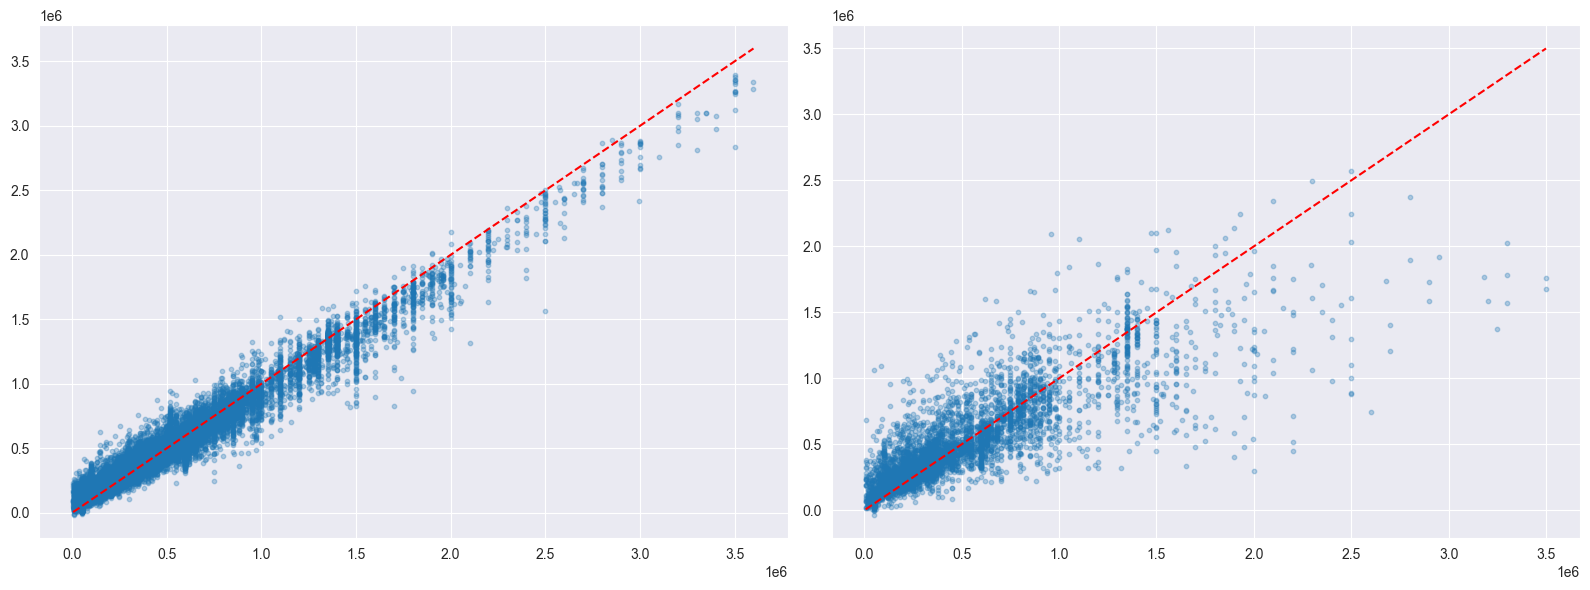

In [233]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_train, y_train_pred, alpha=0.3, s=10)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')

axes[1].scatter(y_test, y_test_pred, alpha=0.3, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.tight_layout()
plt.show()

# Résidus

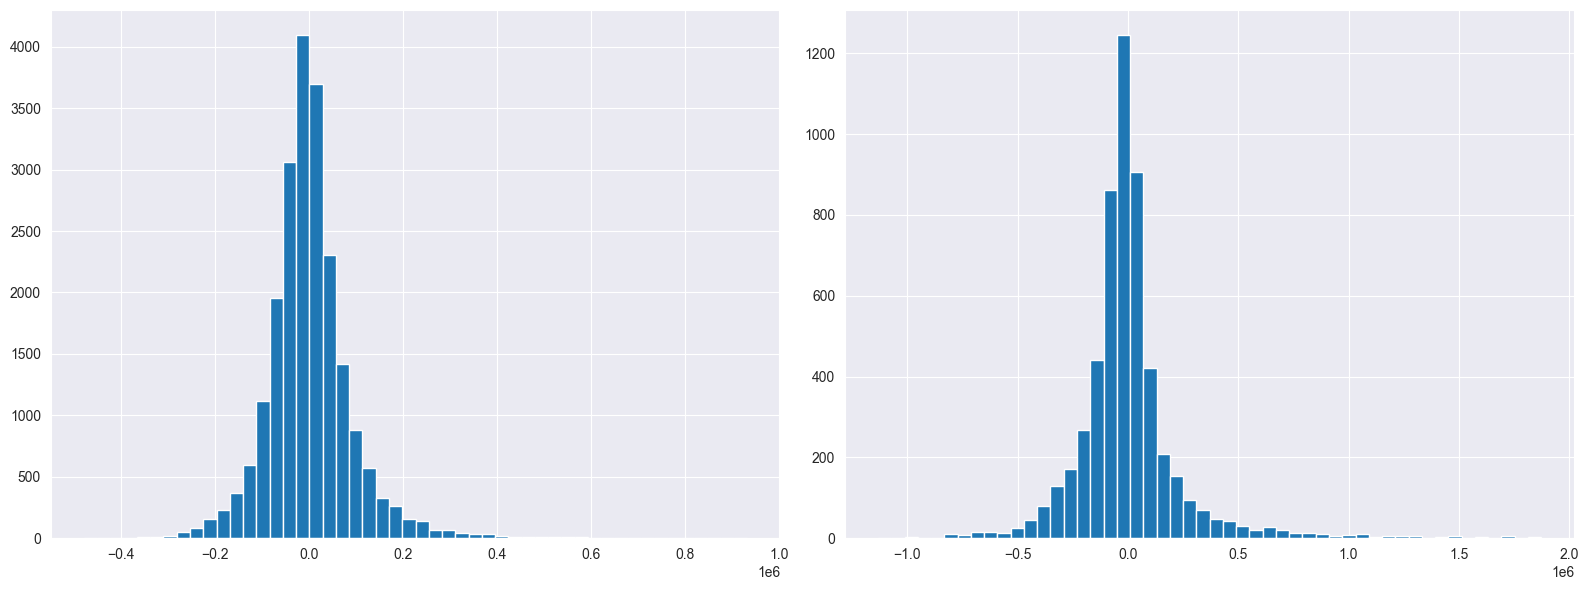

In [234]:
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(residuals_train, bins=50)
axes[1].hist(residuals_test, bins=50)

plt.tight_layout()
plt.show()

# Feature Importance

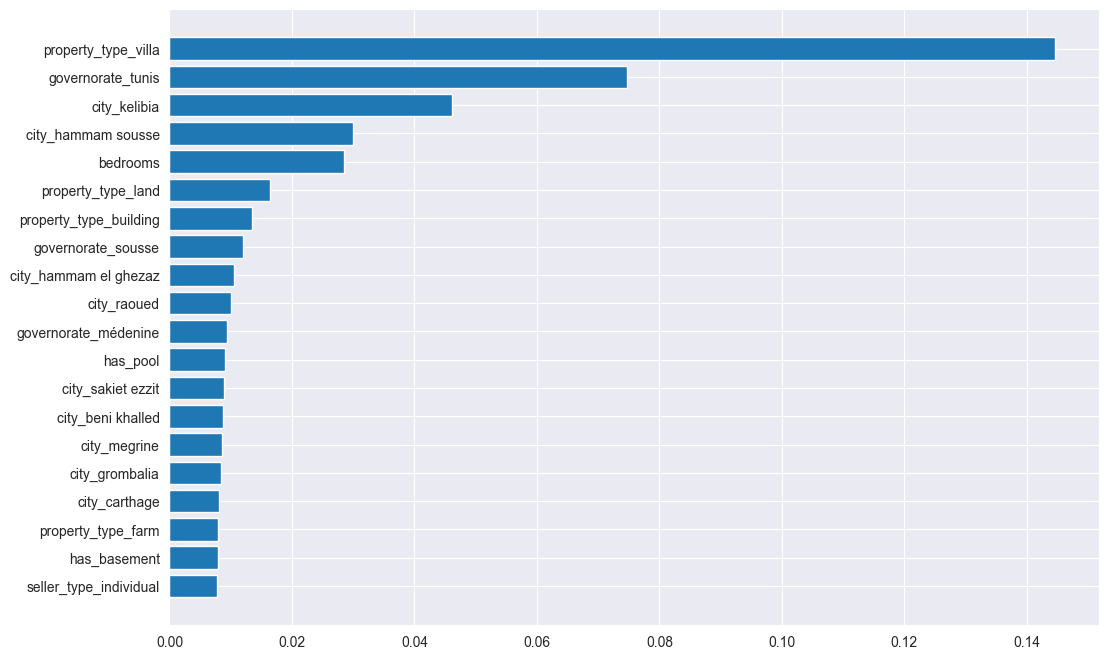

In [235]:
importance = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importance)[::-1][:20]

plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.gca().invert_yaxis()
plt.show()

# SHAP

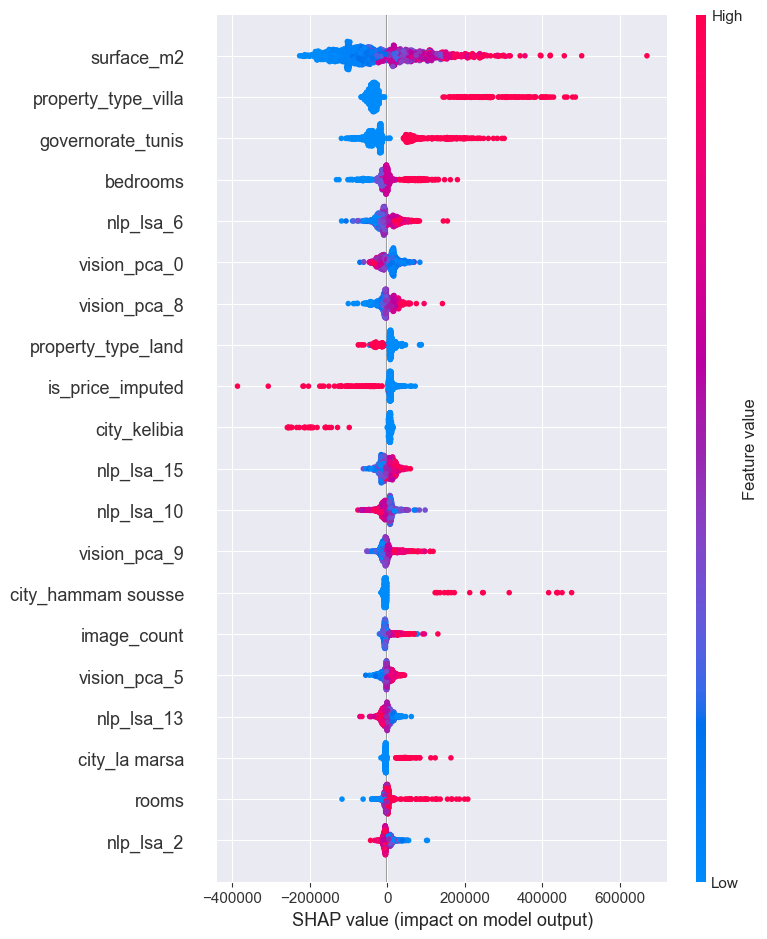

In [236]:
shap_sample_size = 1000

if X_train.shape[0] > shap_sample_size:
    sample_indices = np.random.choice(X_train.shape[0], shap_sample_size, replace=False)
    X_shap = X_train.iloc[sample_indices]
else:
    X_shap = X_train

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, show=False)
plt.show()

In [238]:
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

joblib.dump(model, f"{MODELS_DIR}/xgboost_model_{timestamp}.pkl")

joblib.dump(X.columns.tolist(), f"{MODELS_DIR}/feature_names_{timestamp}.pkl")

joblib.dump(explainer, f"{MODELS_DIR}/shap_explainer_{timestamp}.pkl")

print("Saved!")

Saved!


In [239]:
print("R² TEST:", test_metrics['R²'])
print("MAE:", test_metrics['MAE'])
print("RMSE:", test_metrics['RMSE'])
print("CV RMSE:", cv_rmse.mean())

R² TEST: 0.6797079372677232
MAE: 144733.20281738817
RMSE: 241856.06950771733
CV RMSE: 245456.6031178389
